In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (1).csv


In [6]:
import io

filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (4000, 28)


In [7]:
print("First 5 records:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

First 5 records:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3



Dataset shape:
(4000, 28)

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                   

In [8]:
required_columns = [
    "Farm_ID",
    "Season",
    "Crop",
    "Yield_Tonnes_Ha",
    "Rainfall_mm",
    "Farm_Area_Hectares",
    "Production_Tonnes",
    "Profit_INR",
    "Water_Used_m3",
    "Irrigation_Method"
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print("Missing columns:")
    print(missing_columns)
else:
    print("All required columns are available!")

All required columns are available!


In [9]:
# Remove duplicate records
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

# Identify numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

# Fill missing numerical values with median
for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Total remaining missing values:", df.isnull().sum().sum())

Shape after removing duplicates: (4000, 28)
Total remaining missing values: 0


In [10]:
df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,...,0.87,1.74,15.64,92892,619157,1452831,833674,6146,2.545,34.4
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.9,27.2,60.2,8.3,...,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.009,31.8
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.7,26.3,73.6,7.1,...,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.654,52.7
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.0,17.9,59.7,9.4,...,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.293,29.8
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.8,19.0,55.8,9.2,...,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.363,39.6


In [13]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [14]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = ( df.isnull().mean() * 100 ).sort_values(ascending=False)
missing.head(10)

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [15]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


In [16]:
categorical_columns = df.select_dtypes( include="object" ).columns
for col in categorical_columns:
  print(col)
  print(df[col].nunique(), "unique values")
  print(df[col].dropna().unique()[:20])

Farm_ID
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']
State
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']
District
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']
Crop
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
Season
3 unique values
['Kharif' 'Rabi' 'Zaid']
Irrigation_Method
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [25]:
numeric_columns = df.select_dtypes( include=np.number ).columns
for col in numeric_columns:
  if df[col].isnull().sum() > 0:
    df[col] = df[col].fillna(df[col].median())
print(df.isnull().sum().sum())

0


In [27]:
stats = df[numeric_columns].describe().T
df[numeric_columns].mean()
df[numeric_columns].median()
df[numeric_columns].std()
df[numeric_columns].min()
df[numeric_columns].max()

,0
Farm_Area_Hectares,15.00
Rainfall_mm,1395.20
Avg_Temperature_C,39.70
Humidity_pct,95.00
Sunlight_Hours_Day,11.00
Soil_pH,8.40
Soil_Moisture_pct,47.00
Nitrogen_kg_ha,220.00
Phosphorus_kg_ha,120.00
Potassium_kg_ha,200.00


In [47]:
season_summary = ( df.groupby("Season")[numeric_columns] .agg(["mean", "median", "std"]) )
season_summary

Farm_Area_Hectares                  Rainfall_mm                     \
                     mean median       std        mean median         std   
Season                                                                      
Kharif           7.944924  8.180  4.282328  849.199663  853.1  183.686045   
Rabi             7.752207  7.680  4.179402  437.615366  432.2  175.351345   
Zaid             8.091246  8.085  4.162594  304.654714  288.2  157.238490   

       Avg_Temperature_C                  Humidity_pct  ...     Profit_INR  \
                    mean median       std         mean  ...            std   
Season                                                  ...                  
Kharif         28.454019   28.5  2.510166    71.812591  ...  611549.783883   
Rabi           23.489183   23.5  2.459561    57.893178  ...  489901.254255   
Zaid           31.042088   31.0  2.554911    52.012121  ...  436356.747261   

       Water_Used_m3                      Water_Efficiency_t_per_1000m3  \
                mean  median          std                          mean   
Season                                                                    
Kharif   6102.201237  4469.0  5670.582696                      5.891834   
Rabi     5846.987093  4292.0  5397.648066                      5.186122   
Zaid     6419.893939  4805.0  5734.619854                      4.413239   

                         Disease_Pest_Risk_pct                    
        median       std                  mean median        std  
Season                                                            
Kharif  3.2770  9.833333             54.467903   54.5  10.087931  
Rabi    2.7400  8.258037             40.482114   40.6  10.104157  
Zaid    2.3015  6.930111             38.216667   37.9   9.873938  

[3 rows x 66 columns]

In [29]:
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

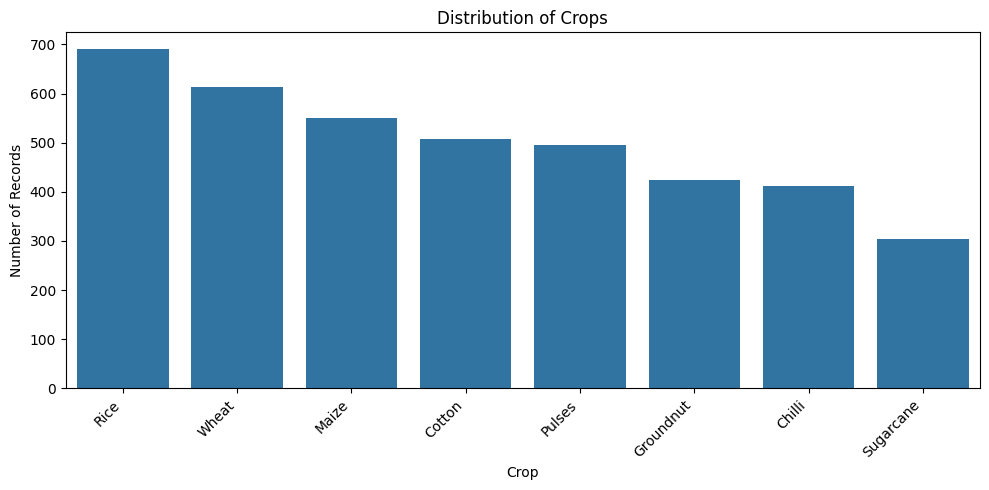

In [31]:
plt.figure(figsize=(10, 5))
sns.countplot( data=df, x="Crop", order=df["Crop"].value_counts().index )
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

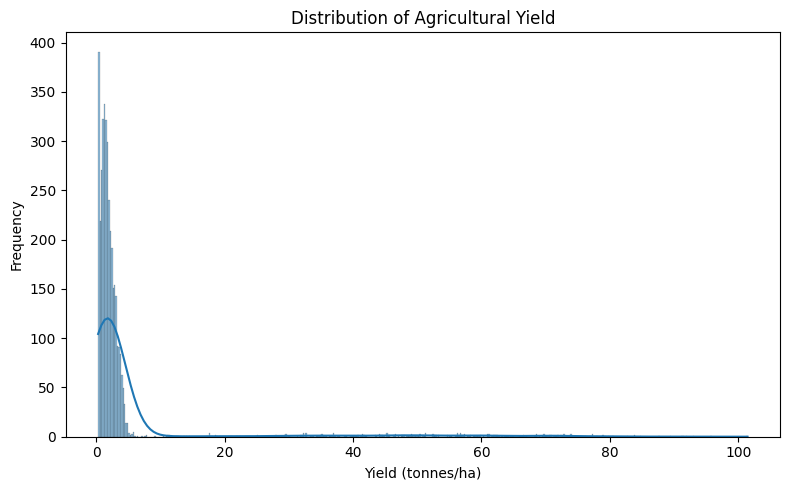

In [32]:
plt.figure(figsize=(8, 5))
sns.histplot( data=df, x="Yield_Tonnes_Ha", kde=True )
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

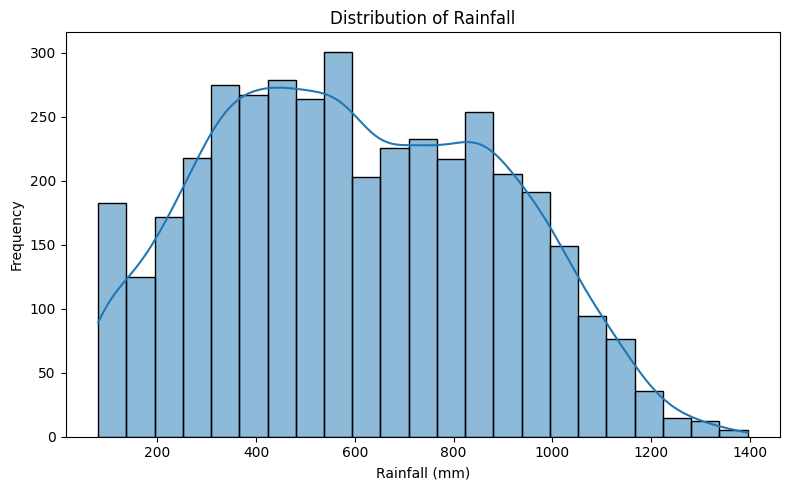

In [33]:
# Univariate: Rainfall distribution
plt.figure(figsize=(8, 5))
sns.histplot( data=df, x="Rainfall_mm", kde=True )
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

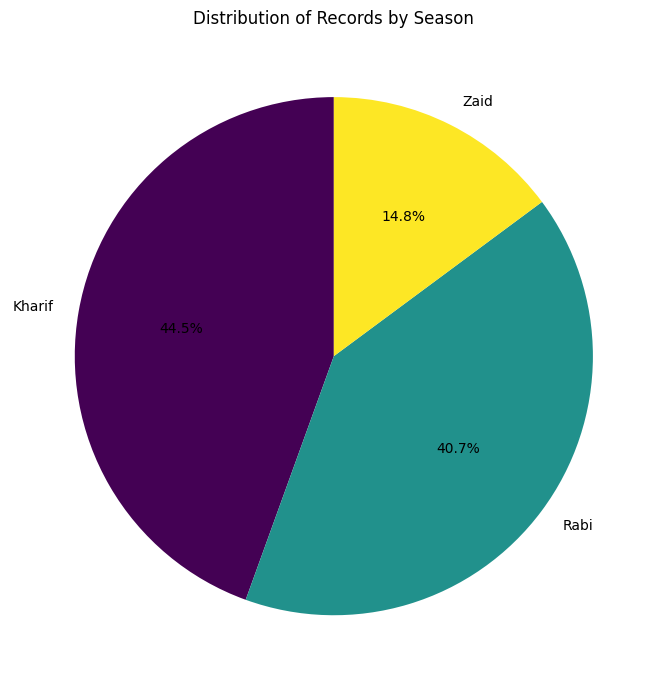

In [34]:
plt.figure(figsize=(7, 7))
df["Season"].value_counts().plot.pie( autopct="%1.1f%%", startangle=90, cmap="viridis" )
plt.title("Distribution of Records by Season")
plt.ylabel("")
plt.tight_layout()
plt.show()

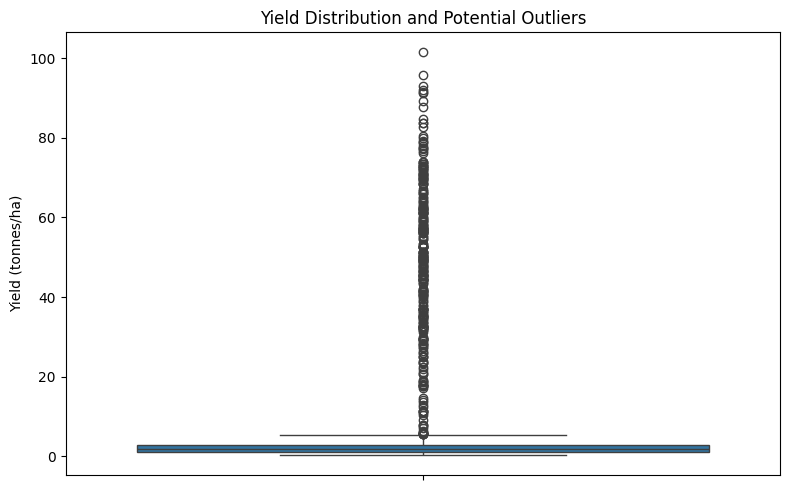

In [36]:
plt.figure(figsize=(8, 5))
sns.boxplot(     data=df,     y="Yield_Tonnes_Ha" )
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

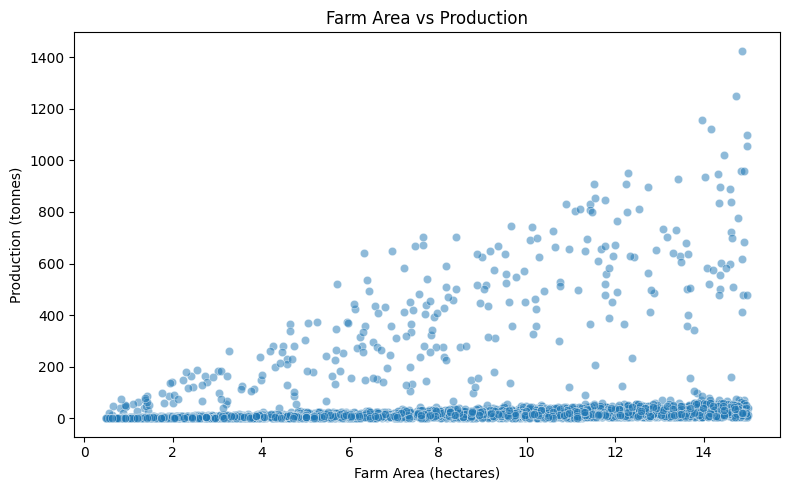

In [37]:
# Bivariate: Farm area vs Production
plt.figure(figsize=(8, 5))
sns.scatterplot( data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5 )
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (hectares)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

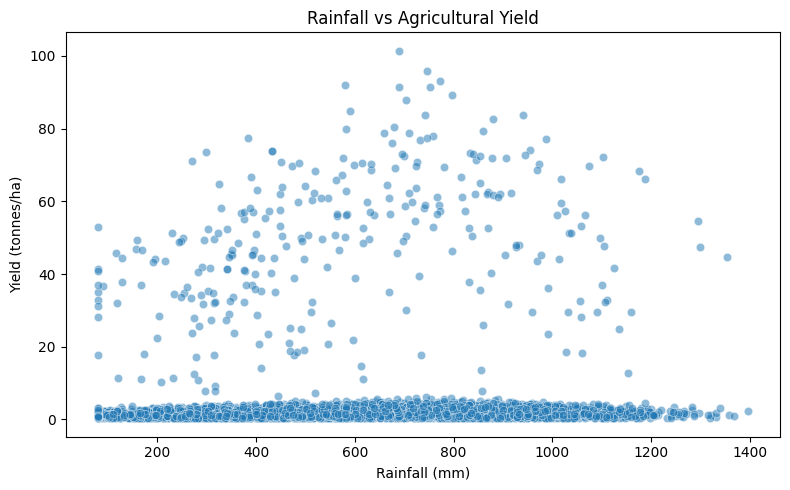

In [38]:
plt.figure(figsize=(8, 5))
sns.scatterplot( data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5 )
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

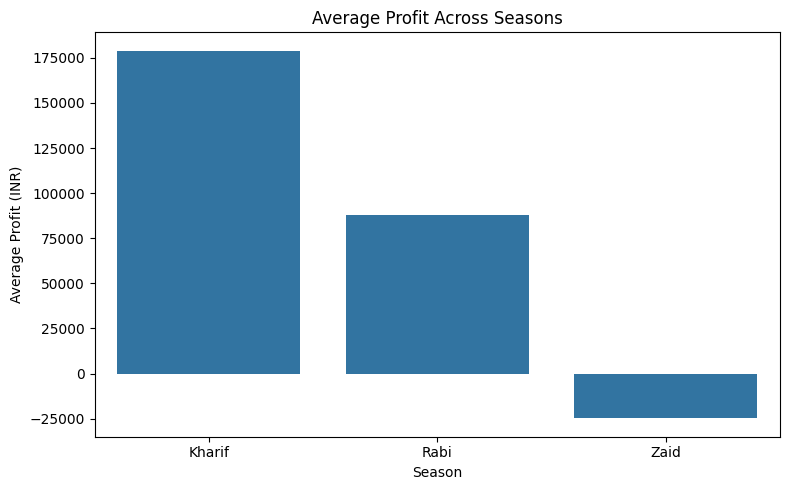

In [39]:
plt.figure(figsize=(8, 5))
sns.barplot( data=df, x="Season", y="Profit_INR", errorbar=None )
plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

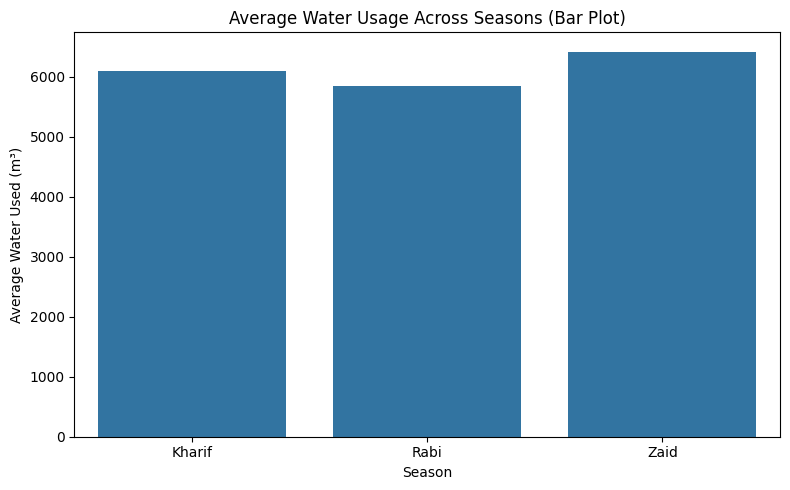

In [40]:
plt.figure(figsize=(8, 5))
sns.barplot( data=df, x="Season", y="Water_Used_m3", errorbar=None )
plt.title("Average Water Usage Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")
plt.tight_layout()
plt.show()

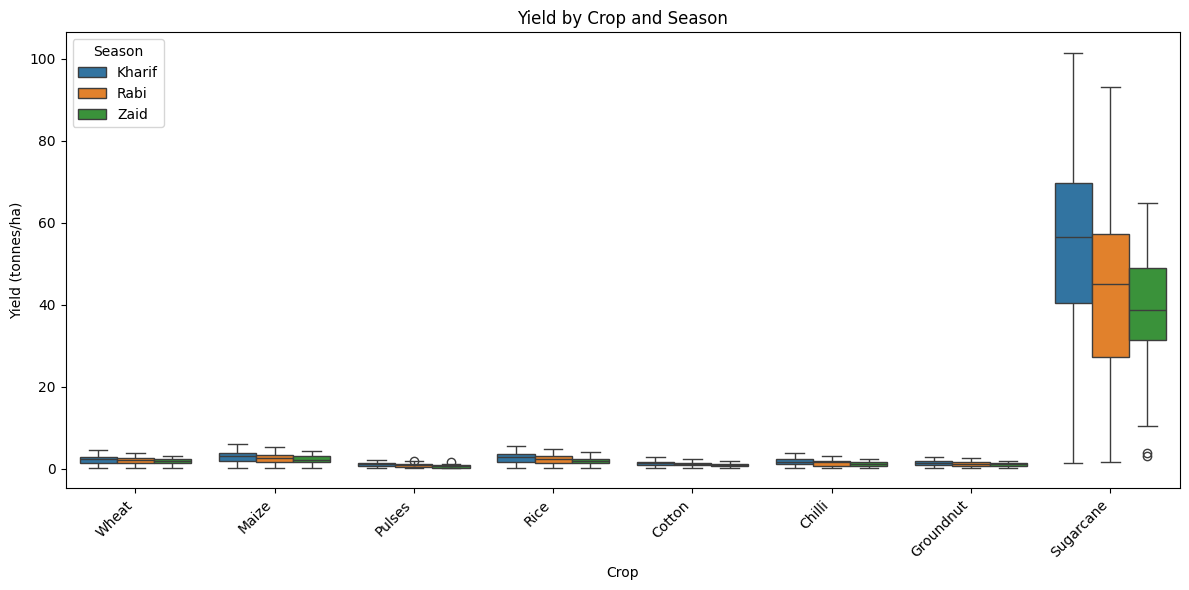

In [41]:
# Multivariate: Season, crop and yield
plt.figure(figsize=(12, 6))
sns.boxplot( data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season" )
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

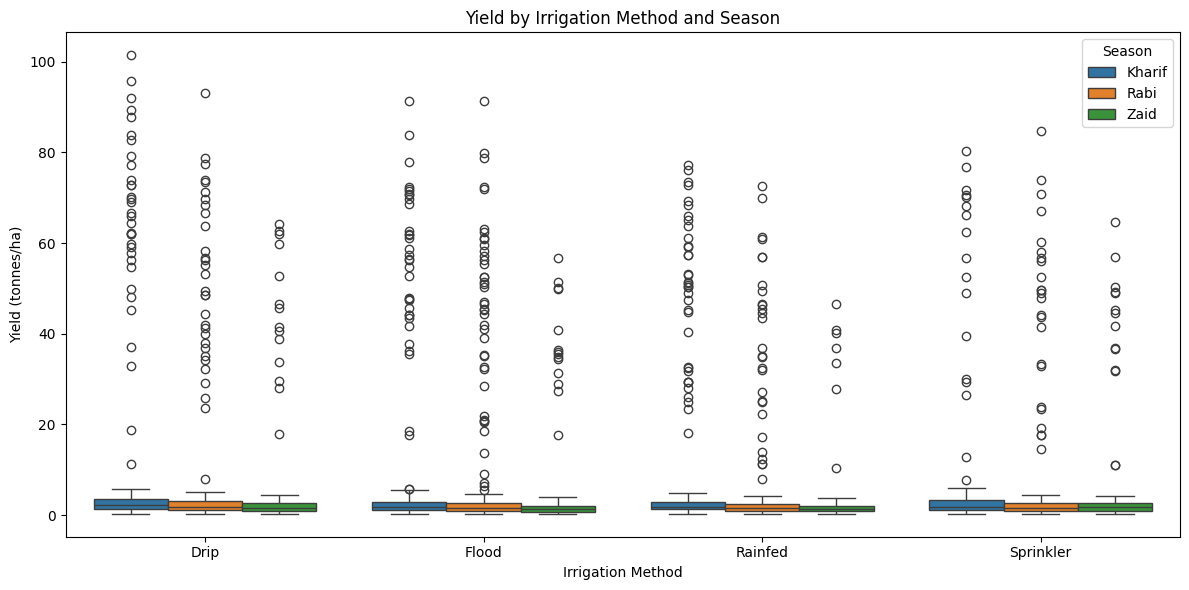

In [42]:
# Multivariate: Season, irrigation and yield
plt.figure(figsize=(12, 6))
sns.boxplot( data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season" )
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()


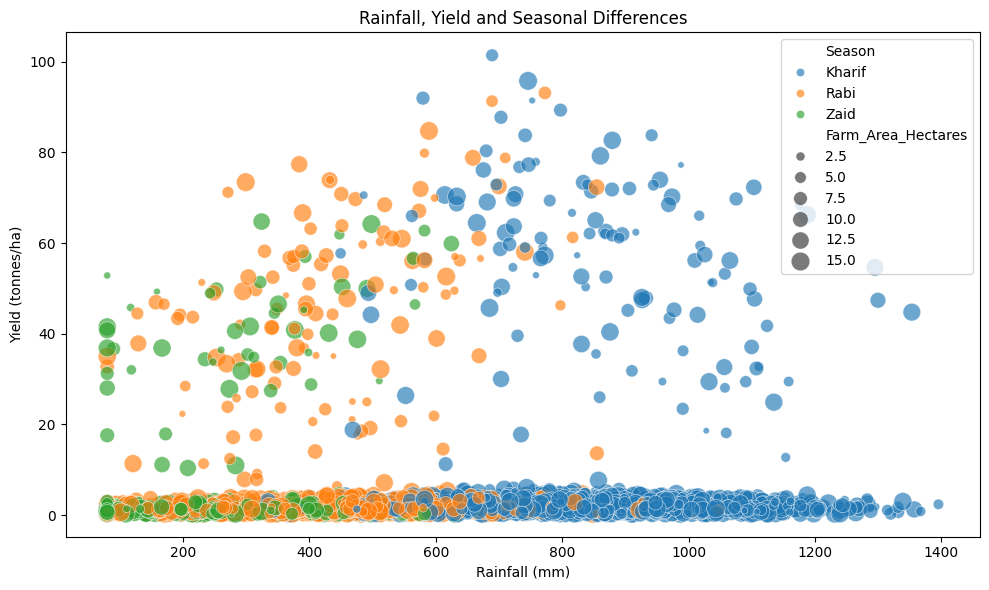

In [43]:
# Multivariate: Rainfall, yield and season
plt.figure(figsize=(10, 6))
sns.scatterplot( data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", size="Farm_Area_Hectares", sizes=(20, 180), alpha=0.65 )
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

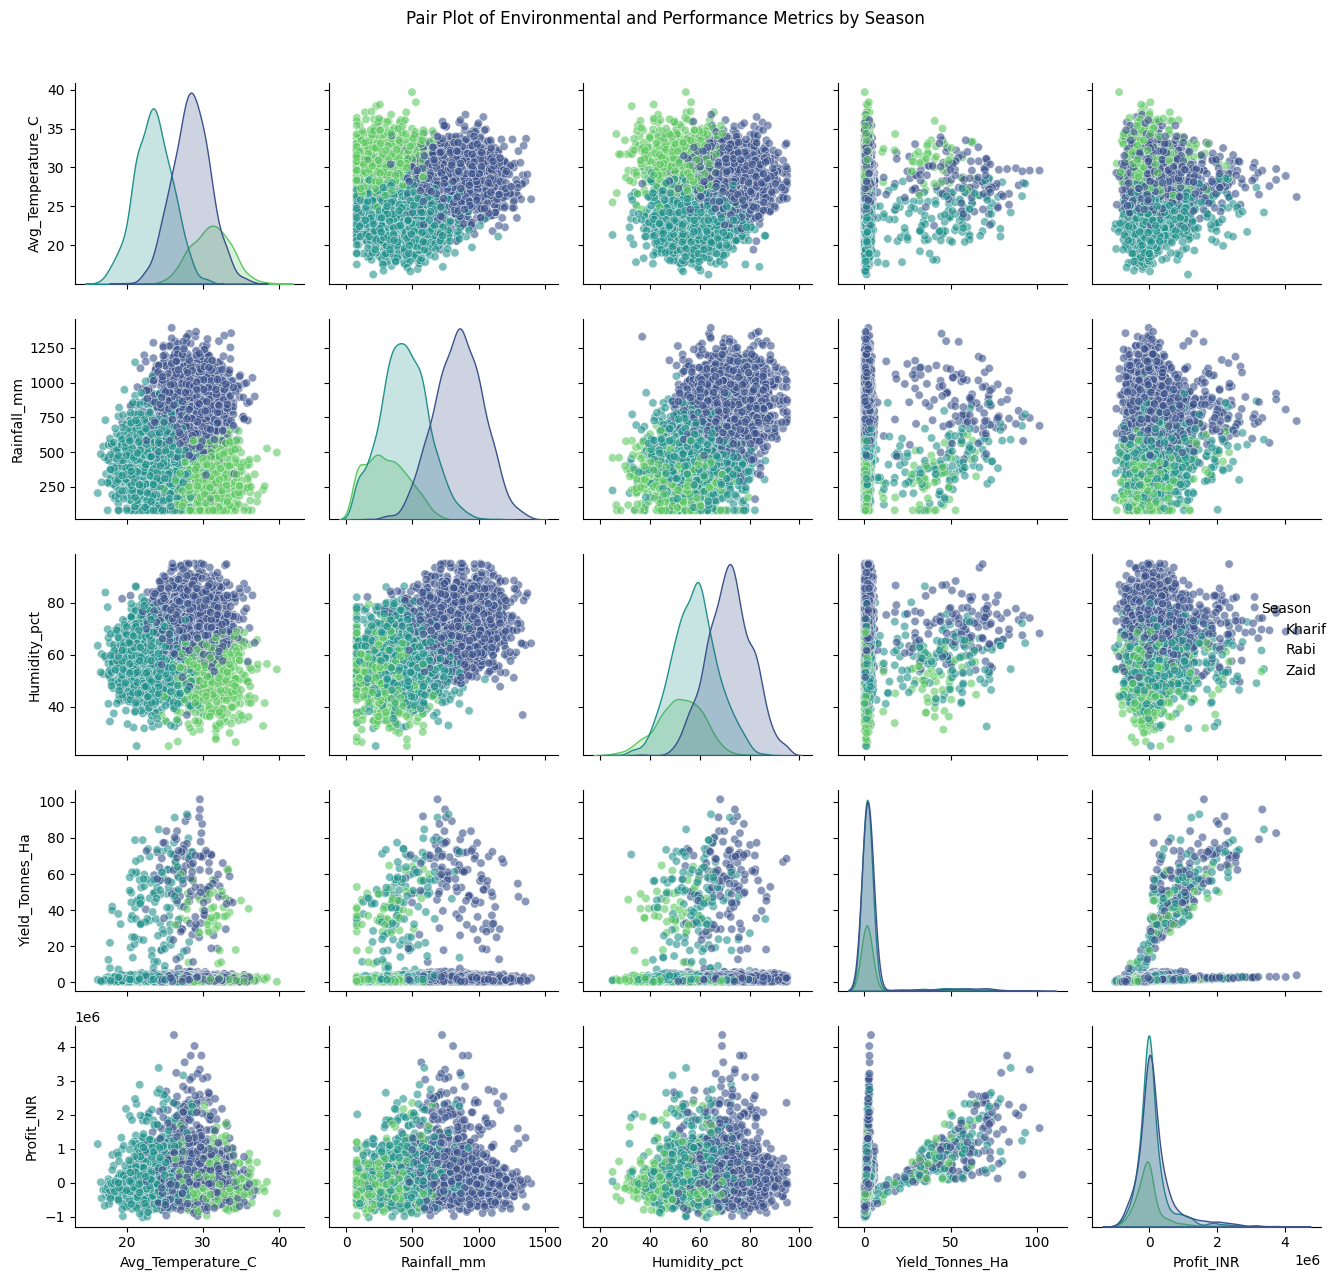

In [44]:
selected_columns = [ "Avg_Temperature_C", "Rainfall_mm", "Humidity_pct", "Yield_Tonnes_Ha", "Profit_INR", "Season" ]
sns.pairplot(     df[selected_columns],     hue="Season",     palette="viridis",     plot_kws={"alpha": 0.6} )
plt.suptitle(     "Pair Plot of Environmental and Performance Metrics by Season",     y=1.02 )
plt.tight_layout()
plt.show()

In [46]:
season_metrics = (     df.groupby("Season")     .agg(         Records=("Farm_ID", "count"),         Average_Yield=("Yield_Tonnes_Ha", "mean"),         Total_Production=("Production_Tonnes", "sum"),         Average_Profit=("Profit_INR", "mean"),         Total_Profit=("Profit_INR", "sum"),         Average_Water_Used=("Water_Used_m3", "mean")     )     .round(2) )
season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,82387.61,178914.65,318289158,6102.20
Rabi,1627,5.04,67498.88,87689.47,142670768,5846.99
Zaid,594,4.64,23098.35,-24804.82,-14734066,6419.89


In [48]:
# Compare crop performance within each season
crop_season_summary = (     df.groupby(["Season", "Crop"])     .agg(         Average_Yield=("Yield_Tonnes_Ha", "mean"),         Average_Profit=("Profit_INR", "mean"),         Average_Water_Efficiency=(             "Water_Efficiency_t_per_1000m3",             "mean"         )     )     .round(2)     .sort_values(         ["Season", "Average_Yield"],         ascending=[True, False]     ) )
crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46      1000790.81                     36.00
       Maize               2.97       -39332.67                      6.05
       Rice                2.70       -64903.40                      2.17
       Wheat               2.25      -105871.87                      4.76
       Chilli              1.73       954380.42                      3.26
       Groundnut           1.48       108265.44                      3.58
       Cotton              1.37       216999.55                      2.13
       Pulses              1.04        43338.90                      3.35
Rabi   Sugarcane          43.29       731612.86                     27.92
       Maize               2.60       -89133.40                      5.46
       Rice                2.32       -98427.87                      1.84
       Wheat               2.06      -119954.57                      4.69
       Chilli              1.47       638572.50                      2.89
       Groundnut           1.23        10416.54                      2.90
       Cotton              1.20       107343.59                      1.94
       Pulses              0.88       -14309.14                      2.70
Zaid   Sugarcane          38.42       583635.80                     23.39
       Maize               2.29      -194049.17                      4.75
       Rice                1.90      -227239.34                      1.53
       Wheat               1.75      -193208.95                      4.02
       Chilli              1.20       448659.09                      2.20
       Groundnut           1.04       -68872.50                      2.47
       Cotton              0.96       -53925.34                      1.49
       Pulses              0.67      -139227.81                      1.95

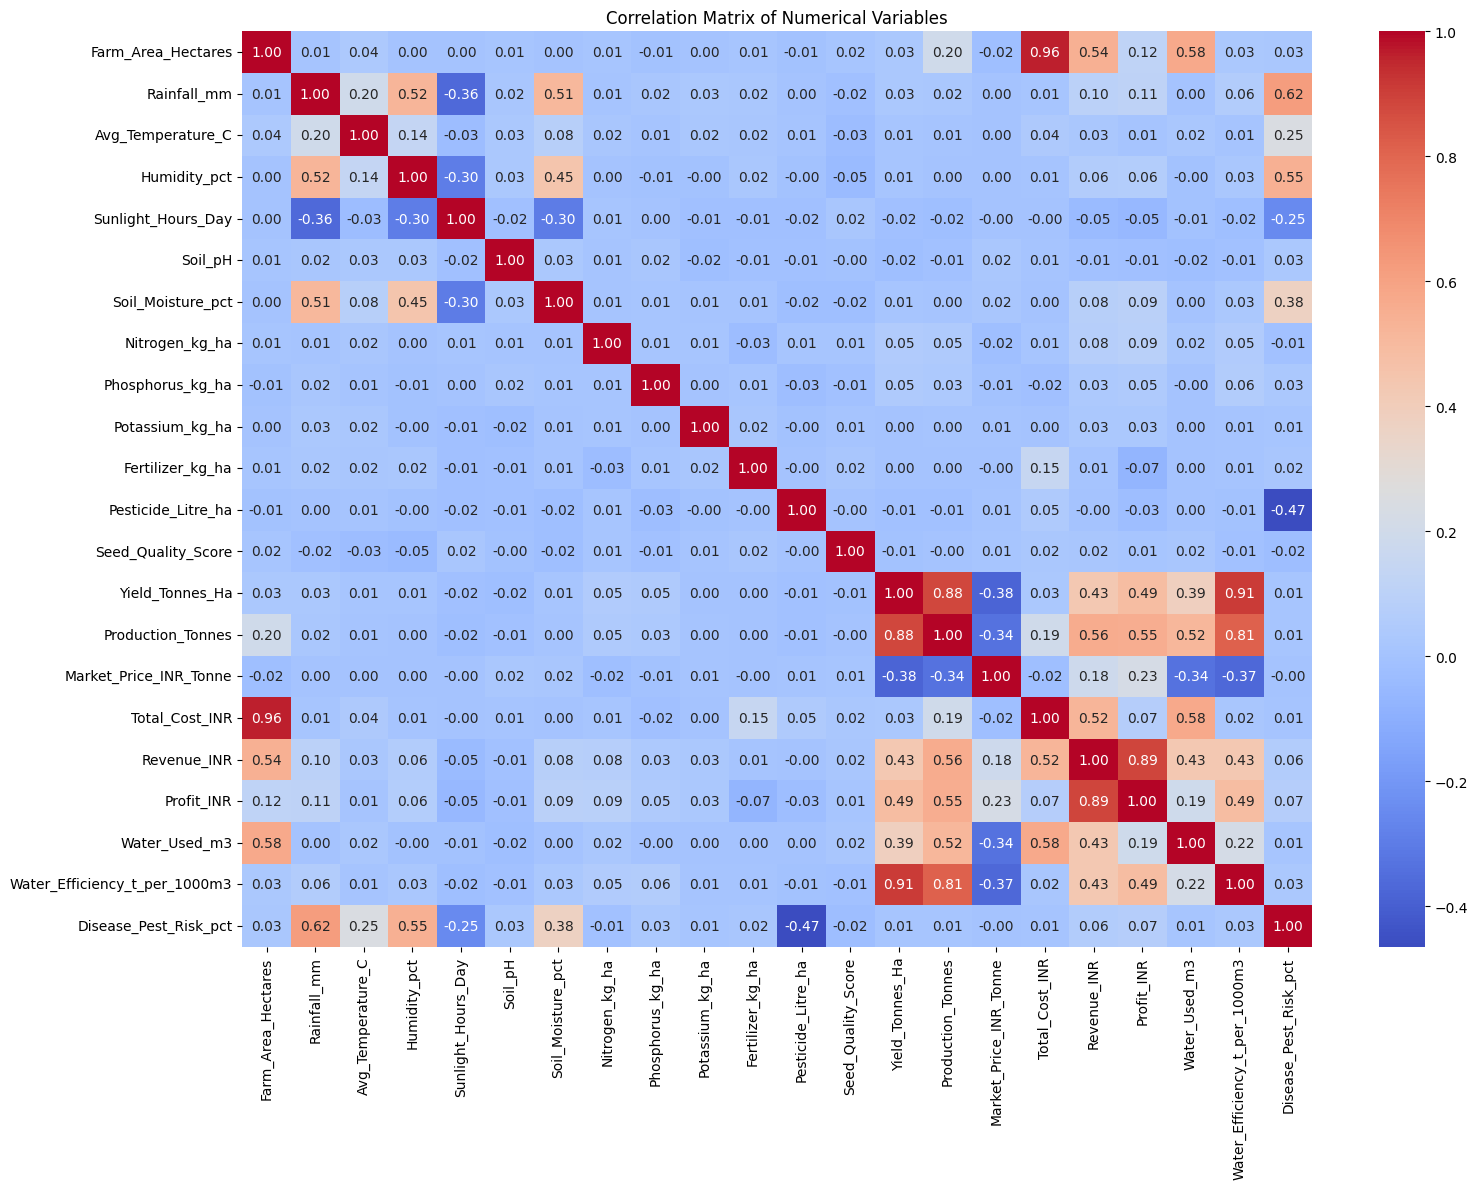

In [49]:
correlation_matrix = df[numeric_columns].corr()
plt.figure(figsize=(16, 12))
sns.heatmap( correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f" )
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()